# Лаборатори 3: CSP хэрэгжүүлэлт
Backtracking хайлт ба MRV, degree, LCV heuristic

## 1. Зорилго
Энэ лабораторийн ажлаар CSP (Constraint Satisfaction Problem)-ийн үндсэн бүтэц болох хувьсагч, домэйн, хязгаарлалтыг ашиглан Backtracking хайлтаар хэд хэдэн бодлого жишээн дээр ажиллана.  Мөн хайлтын дарааллыг тодорхойлох MRV, Degree, LCV heuristic-үүдийг кодондоо нэмж, map coloring болон N-Queens бодлогууд дээр туршина.

## 2. Онол
CSP нь хувьсагчид утга оноохдоо өгөгдсөн бүх хязгаарлалтыг хангах бодлого юм. CSP нь үндсэндээ хувьсагч (X), домэйн (D), хязгаарлалт (C) гэсэн гурван хэсгээс бүрдэнэ. Бүх хувьсагчид утга авсан бөгөөд ямар ч хязгаарлалт зөрчөөгүй бол тухайн оноолтыг шийд гэж үзнэ.
Backtracking нь нэг удаад нэг хувьсагчид утга оноож явдаг. Хэрэв тухайн утга өмнөх оноолттой зөрчилдвөл тэр утгыг орхиж өөр утга орлуулна. Боломжит утга дуусвал өмнөх хувьсагч руу буцна. Өөрөөр хэлбэл DFS хэлбэрээр хайлт хийж, зөрчил гарсан хэсгийг цааш үргэлжлүүлэн шалгахгүйгээр тасалдаг.
MRV (Minimum Remaining Values) нь боломжит утга хамгийн цөөн үлдсэн хувьсагчийг түрүүлж сонгоно. Ингэснээр шийдгүй болох хувьсагчийг эрт илрүүлнэ.
Degree нь MRV-ийн утга тэнцсэн үед оноогдоогүй хөрштэй хамгийн олон зангилаатай холбогдсон хувьсагчийг сонгоно.
Харин LCV (Least Constraining Value) нь сонгосон хувьсагчийн утгуудаас хөршүүдийн боломжит сонголтыг хамгийн бага хасах утгыг түрүүлж шалгана.

## 3. Аргачлал
Лаборатори дээр бичсэн map coloring кодыг шууд ажиллуулахын оронд ерөнхий CSP solver болгон өөрчилсөн. Solver нь хувьсагч, домэйн, хөршүүд, constraint функц болон хайлтын зангилааны тоог ашиглана.

**CSP класс ба хөршийн шалгалт**

In [ ]:
class TooSlow(Exception):
    """Зангилааны тоо хязгаараас хэтэрсэн үед үүснэ."""


class CSP:
    def __init__(self, variables, domains, neighbors, constraint):
        self.variables = variables     
        self.domains = domains          
        self.neighbors = neighbors      
        self.constraint = constraint    
        self.nodes = 0                 

    def is_consistent(self, var, value, assignment):
        """var-д value оноовол оноогдсон хөршүүдтэй зөрчилдөх эсэхийг шалгана."""
        for n in self.neighbors[var]:
            if n in assignment and not self.constraint(var, value, n, assignment[n]):
                return False
        return True

    def unassigned(self, assignment):
        """Оноолтод ороогүй хувьсагчдын жагсаалтыг буцаана."""
        return [v for v in self.variables if v not in assignment]

**Газрын зураг будах бодлого.** Map coloring бодлогод 7 мужийг хувьсагч, улаан, ногоон, цэнхэр өнгийг домэйн болгон авч, хөрш мужууд ижил өнгөтэй байж болохгүй гэсэн хязгаарлалт тавьсан. Энэ нь лекц дээрх Австралийн газрын зураг будах CSP загвартай адил.

In [ ]:
def make_map_csp(colors=("red", "green", "blue")):
    """Австралийн газрын зургийг CSP хэлбэрээр буцаана."""
    variables = ["WA", "NT", "SA", "Q", "NSW", "V", "T"]
    edges = [("WA", "NT"), ("WA", "SA"), ("NT", "SA"), ("NT", "Q"), ("SA", "Q"),
             ("SA", "NSW"), ("SA", "V"), ("Q", "NSW"), ("NSW", "V")]
    domains = {v: list(colors) for v in variables}
    neighbors = {v: [] for v in variables}
    for a, b in edges:                 
        neighbors[a].append(b)
        neighbors[b].append(a)
    return CSP(variables, domains, neighbors, lambda A, a, B, b: a != b)

**Backtracking хайлт.** Хайлтын зангилаа бүрт хувьсагч сонгож, домэйны утгуудыг нэг нэгээр нь оноож, зөрчвөл буцна. `check_solution()` нь хайлтаас хараат бусаар шийдийг шалгана.

In [ ]:
def select_unassigned_variable(csp, assignment):
    """Heuristic-гүй: жагсаалтын эхнийхийг авна."""
    return csp.unassigned(assignment)[0]


def backtrack(csp, assignment):
    """Рекурсив хайлт: утга оноож, зөрчвөл буцна."""
    if len(assignment) == len(csp.variables):
        return dict(assignment)
    var = select_unassigned_variable(csp, assignment)
    for value in csp.domains[var]:
        if csp.is_consistent(var, value, assignment):
            csp.nodes += 1
            assignment[var] = value
            result = backtrack(csp, assignment)
            if result is not None:
                return result
            del assignment[var]     
    return None


def backtracking_search(csp):
    """nodes-ийг тэглээд хоосон оноолтоос хайлт эхлүүлнэ."""
    csp.nodes = 0
    return backtrack(csp, {})


def check_solution(csp, assignment):
    """Хайлтаас хараат бусаар бүрэн байдал ба хязгаарлалтыг шалгана."""
    if assignment is None or set(assignment) != set(csp.variables):
        return False
    for a in csp.variables:
        for b in csp.neighbors[a]:
            if not csp.constraint(a, assignment[a], b, assignment[b]):
                return False
    return True

**N-Queens бодлого.** Q(i) нь i-р мөрөнд байрлах хатныг илэрхийлэн, домэйн нь 1-ээс N хүртэл байна. Хоёр хатан нэг багана болон нэг диагональ дээр давхцахгүй байх хязгаарлалт хийсэн.

In [ ]:
def make_queens_csp(n):
    """Мөр бүр нэг хувьсагч, домэйн нь баганын дугаар."""
    variables = list(range(n))
    domains = {r: list(range(n)) for r in variables}
    neighbors = {r: [x for x in variables if x != r] for r in variables}

    def constraint(A, a, B, b):
        return a != b and abs(a - b) != abs(A - B)

    return CSP(variables, domains, neighbors, constraint)


def count_solutions(csp):
    """Шийд бүрийг тоолж хайлтаа үргэлжлүүлнэ."""
    def rec(assignment):
        if len(assignment) == len(csp.variables):
            return 1
        var = select_unassigned_variable(csp, assignment)
        total = 0
        for value in csp.domains[var]:
            if csp.is_consistent(var, value, assignment):
                assignment[var] = value
                total += rec(assignment)
                del assignment[var]
        return total
    return rec({})


def print_board(assignment, n):
    """Хатан байгаа нүдийг Q, хоосон нүдийг . гэж хэвлэнэ."""
    for r in range(n):
        print(" ".join("Q" if assignment[r] == c else "." for c in range(n)))

**Heuristic-ууд.** MRV болон Degree-г хувьсагч сонгох хэсэгт, LCV-г тухайн хувьсагчийн утгыг сонгох хэсэгт тусгасан. Эдгээрийг тус бүрээр нь туршихын тулд use_mrv, use_degree, use_lcv параметр ашиглан бичив.

In [10]:
def legal_values(csp, var, assignment):
    """Одоогийн оноолттой зөрчилгүй утгууд."""
    return [x for x in csp.domains[var] if csp.is_consistent(var, x, assignment)]


def select_unassigned_variable(csp, assignment, use_mrv=True, use_degree=True):
    """MRV (боломжит утга хамгийн цөөн), tie-breaker нь degree."""
    free = csp.unassigned(assignment)
    if not use_mrv:
        return free[0]

    def legal(v):
        return len(legal_values(csp, v, assignment))

    def degree(v):
        return sum(1 for n in csp.neighbors[v] if n not in assignment)

    if use_degree:
        return min(free, key=lambda v: (legal(v), -degree(v)))
    return min(free, key=legal)


def order_domain_values(csp, var, assignment, use_lcv=True):
    """LCV: хөршүүдийн боломжит утгыг хамгийн бага хасах утгыг түрүүлж өгнө."""
    values = legal_values(csp, var, assignment)
    if not use_lcv:
        return values

    def removed(x):
        total = 0
        for n in csp.neighbors[var]:
            if n in assignment:
                continue
            for y in legal_values(csp, n, assignment):
                if not csp.constraint(var, x, n, y):
                    total += 1
        return total

    return sorted(values, key=removed)


def backtrack(csp, assignment, use_mrv=False, use_degree=False,
              use_lcv=False, limit=None):
    """Heuristic-ийг асаах/унтраах параметртэй рекурсив хайлт."""
    if len(assignment) == len(csp.variables):
        return dict(assignment)
    var = select_unassigned_variable(csp, assignment, use_mrv, use_degree)
    for value in order_domain_values(csp, var, assignment, use_lcv):
        csp.nodes += 1
        if limit and csp.nodes > limit:
            raise TooSlow
        assignment[var] = value
        result = backtrack(csp, assignment, use_mrv, use_degree, use_lcv, limit)
        if result is not None:
            return result
        del assignment[var]
    return None


def backtracking_search(csp, **options):
    """nodes-ийг тэглээд хайлт эхлүүлнэ."""
    csp.nodes = 0
    return backtrack(csp, {}, **options)


def count_solutions(csp, **options):
    """Heuristic-тэй үед шийдийн тоо өөрчлөгдөхгүй."""
    def rec(assignment):
        if len(assignment) == len(csp.variables):
            return 1
        var = select_unassigned_variable(csp, assignment,
                                         options.get("use_mrv", False),
                                         options.get("use_degree", False))
        total = 0
        for value in order_domain_values(csp, var, assignment,
                                         options.get("use_lcv", False)):
            assignment[var] = value
            total += rec(assignment)
            del assignment[var]
        return total
    return rec({})

## 4. Үр дүн
### 4.1 Алхам бүрийн шалгалт

| Шалгалт | Хүлээгдсэн | Гарсан |
|---|---|---|
| SA, T, WA-ийн хөршийн тоо | 5, 0, 2 | 5, 0, 2 |
| Map, check_solution() | True | True (7 зангилаа) |
| N-Queens шийдийн тоо, N = 1 ээс 8 хүртэл | 1, 0, 0, 2, 10, 4, 40, 92 | 1, 0, 0, 2, 10, 4, 40, 92 |
| WA-улаан үед MRV-ийн шийд | NT юм уу SA | NT |
| MRV-тэй 8-Queens шийдийн тоо | 92 | 92 |
| Хоосон оноолттой үед Degree | SA | SA |
| WA-улаан, NT-ногоон үед Q-ийн дараалал (LCV) | Улаан, цэнхэр | Улаан, цэнхэр |

**Шалгах:** 3 хувьсагчтай жижиг CSP дээр нэг зөрчилтэй, нэг зөрчилгүй тохиолдол.

In [ ]:
small = CSP(["X", "Y", "Z"],
            {v: [1, 2] for v in "XYZ"},
            {"X": ["Y"], "Y": ["X", "Z"], "Z": ["Y"]},
            lambda A, a, B, b: a != b)
print(small.is_consistent("Y", 1, {"X": 1}))   
print(small.is_consistent("Y", 2, {"X": 1}))  

False
True


**Шалгах:** SA-ийн хөршийн тоо 5, T-ийнх 0, WA-ийнх 2.

In [4]:
m = make_map_csp()
print(len(m.neighbors["SA"]), len(m.neighbors["T"]), len(m.neighbors["WA"]))

5 0 2


**Шалгах:** газрын зургийг будаж, шийдийг шалгана.

In [6]:
m = make_map_csp()
sol = backtracking_search(m)
print(sol)
print("check_solution:", check_solution(m, sol), "| зангилаа:", m.nodes)

{'WA': 'red', 'NT': 'green', 'SA': 'blue', 'Q': 'red', 'NSW': 'green', 'V': 'red', 'T': 'red'}
check_solution: True | зангилаа: 7


Map coloring бодлогын шийд: WA-улаан, NT-ногоон,  SA-цэнхэр, Q-улаан, NSW-ногоон, V-улаан, T-улаан. Хөрш мужууд өөр өнгөтэй байна.

Шийдийг граф хэлбэрээр дүрслэв (Зураг 1).

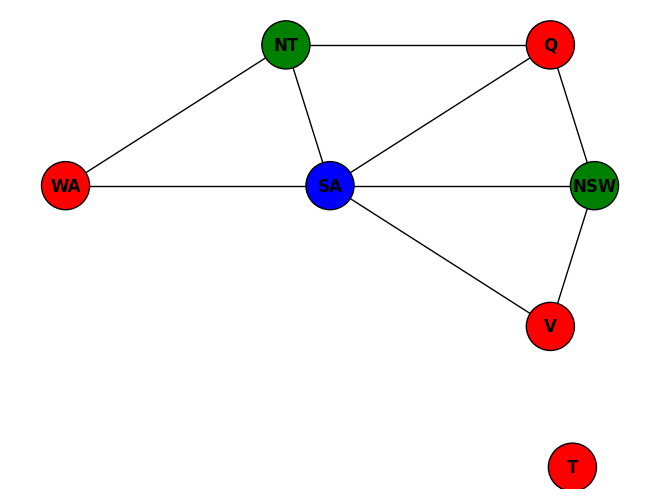

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph([(a, b) for a in m.variables for b in m.neighbors[a] if a < b])
G.add_node("T")
pos = {"WA": (0, 1), "NT": (1, 2), "SA": (1.2, 1), "Q": (2.2, 2),
       "NSW": (2.4, 1), "V": (2.2, 0), "T": (2.3, -1)}
nx.draw(G, pos, node_color=[sol[v] for v in G.nodes()], node_size=1200,
        with_labels=True, font_weight="bold", edgecolors="black")
plt.savefig("map.png", dpi=150, bbox_inches="tight")
plt.show()

**Шалгах:** WA = red үед NT эсвэл SA сонгогдоно. MRV-тэй 8-Queens-ийн шийд 92 хэвээр.

In [11]:
print(select_unassigned_variable(make_map_csp(), {"WA": "red"}, use_degree=False))
print(count_solutions(make_queens_csp(8), use_mrv=True))

NT
92


**Шалгах:** хоосон оноолттой үед SA сонгогдоно.

In [12]:
print(select_unassigned_variable(make_map_csp(), {}))

SA


**Шалгах:** WA = red, NT = green үед Q-ийн утгуудын дараалал red, blue байна.

In [13]:
print(order_domain_values(make_map_csp(), "Q", {"WA": "red", "NT": "green"}))

['red', 'blue']


**N-Queens-ийн нэг шийд (4-Queens):**

In [9]:
print([count_solutions(make_queens_csp(n)) for n in range(1, 9)])
q = make_queens_csp(4)
print_board(backtracking_search(q), 4)

[1, 0, 0, 2, 10, 4, 40, 92]
. Q . .
. . . Q
Q . . .
. . Q .


### 4.2 Функцуудын харьцуулалт
Эхний шийд олтол оруулсан зангилааны тоо:

In [14]:
CONFIGS = {
    "A. Heuristic-гүй":      dict(use_mrv=False, use_degree=False, use_lcv=False),
    "B. MRV":                dict(use_mrv=True,  use_degree=False, use_lcv=False),
    "C. MRV + Degree":       dict(use_mrv=True,  use_degree=True,  use_lcv=False),
    "D. MRV + Degree + LCV": dict(use_mrv=True,  use_degree=True,  use_lcv=True),
}
PROBLEMS = {
    "Газрын зураг": make_map_csp,
    "8-Queens": lambda: make_queens_csp(8),
    "12-Queens": lambda: make_queens_csp(12),
    "16-Queens": lambda: make_queens_csp(16),
}
LIMIT = 1_000_000


def run(make_csp, options):
    """Эхний шийд хүртэлх зангилааны тоо; хязгаараас хэтэрвэл 'хэт удаан'."""
    csp = make_csp()
    try:
        solution = backtracking_search(csp, limit=LIMIT, **options)
    except TooSlow:
        return "хэт удаан"
    assert check_solution(csp, solution)
    return csp.nodes


print(f"{'Тохиргоо':24}" + "".join(f"{p:>14}" for p in PROBLEMS))
for name, opts in CONFIGS.items():
    print(f"{name:24}" + "".join(f"{run(mk, opts):>14}" for mk in PROBLEMS.values()))

Тохиргоо                  Газрын зураг      8-Queens     12-Queens     16-Queens
A. Heuristic-гүй                     7           113           261         10052
B. MRV                               7            75           153            44
C. MRV + Degree                      7            75           153            44


D. MRV + Degree + LCV                7            39            32           332

Бүгд 1000000 зангилааны хязгаарт багтсан тул удаан тохиолдол гараагүй.

### 4.3 Асуултын хариулт
1. Аль тохиргоо хамгийн их хэмнэлт өгсөн бэ? MRV нэмэхэд 16-Queens дээр зангилаа 10052-оос 44 болж, хамгийн их хэмнэлт өгсөн. 12-Queens дээр D тохиргоо хамгийн их хэмнэлт буюу 261-аас 32.
2. N-Queens дээр Degree нэмэхэд зангилааны тоо яагаад өөрчлөгдөөгүй вэ? Мөр бүр бусад бүх мөртэй хөрш тул оноогдоогүй хөршийн тоо бүх хувьсагчид тэнцүү байна. Иймд Degree хувьсагчдыг ялгаж чадахгүй, B ба C нөхцөл адил хайлт хийсэн.
3. LCV нь бүх тохиолдолд хайлтыг хурдасгасан уу? Үгүй. 8-Queens дээр 75-аас 39 болсон ба 12-Queens дээр 153-аас 32 болж хурдасгасан боловч 16-Queens дээр 44-өөс 332 болж өссөн. LCV нь утга бүрийг хөршүүдтэй нь үнэлдэг тул эхний шийдэд хүрэх замыг үргэлж богиносгодоггүй.

## 5. Дүгнэлт
Энэ лабораторийн ажлаар CSP-ийн үндсэн бүтэц дээр тулгуурласан нэг Backtracking solver хийж, map coloring болон N-Queens бодлогууд дээр ажиллууллаа. MRV нь боломжит утга цөөн болсон хувьсагчийг түрүүлж сонгосноор хайлтыг нэлээд багасгасан. Degree нь N-Queens шиг бүх хувьсагч хоорондоо холбогдсон бодлогод ялгаа гаргаагүй. LCV-ийн хувьд зарим N-ийн үед хайлтыг багасгасан боловч бүх тохиолдолд заавал хурдан болдоггүй нь туршилтаас харагдсан. Онол дээр үзсэн мэдлэгээ практик дээр хэрэгжүүлэн туршиж үзлээ.